In [ ]:
import torch
if(not torch.cuda.is_available()): print("No CUDA applicable GPU")
else: gpu_device = torch.cuda.get_device_name(0); print("CUDA applicable GPU found:", end=" "); print(gpu_device)

CUDA applicable GPU found: Tesla T4


In [ ]:
#install ultralytics package to work within YOLO
!pip install ultralytics

Saving Screenshot 2026-08-10 174800.png to Screenshot 2026-08-10 174800.png

image 1/1 /content/Screenshot 2026-08-10 174800.png: 640x384 6 persons, 2 horses, 2 elephants, 3 clocks, 6.2ms
Speed: 2.1ms preprocess, 6.2ms inference, 4.8ms postprocess per image at shape (1, 3, 640, 384)
ultralytics.engine.results.Boxes object with attributes:

cls: tensor([17., 74.,  0., 20.,  0., 74.,  0., 74.,  0.,  0., 20.,  0., 17.], device='cuda:0')
conf: tensor([0.7676, 0.7424, 0.6021, 0.5712, 0.5471, 0.5285, 0.5152, 0.5132, 0.5118, 0.4801, 0.3184, 0.2839, 0.2630], device='cuda:0')
data: tensor([[6.6072e+02, 6.5444e+02, 8.4600e+02, 1.1551e+03, 7.6759e-01, 1.7000e+01],
        [1.2155e+00, 2.0885e+00, 8.4625e+01, 6.9998e+01, 7.4241e-01, 7.4000e+01],
        [5.6835e+02, 5.3335e+02, 6.7168e+02, 8.2080e+02, 6.0206e-01, 0.0000e+00],
        [3.0076e+00, 5.4639e+02, 8.0258e+01, 6.6349e+02, 5.7116e-01, 2.0000e+01],
        [6.1405e+02, 4.9950e+02, 8.2642e+02, 9.3829e+02, 5.4706e-01, 0.0000e+00],
        [8

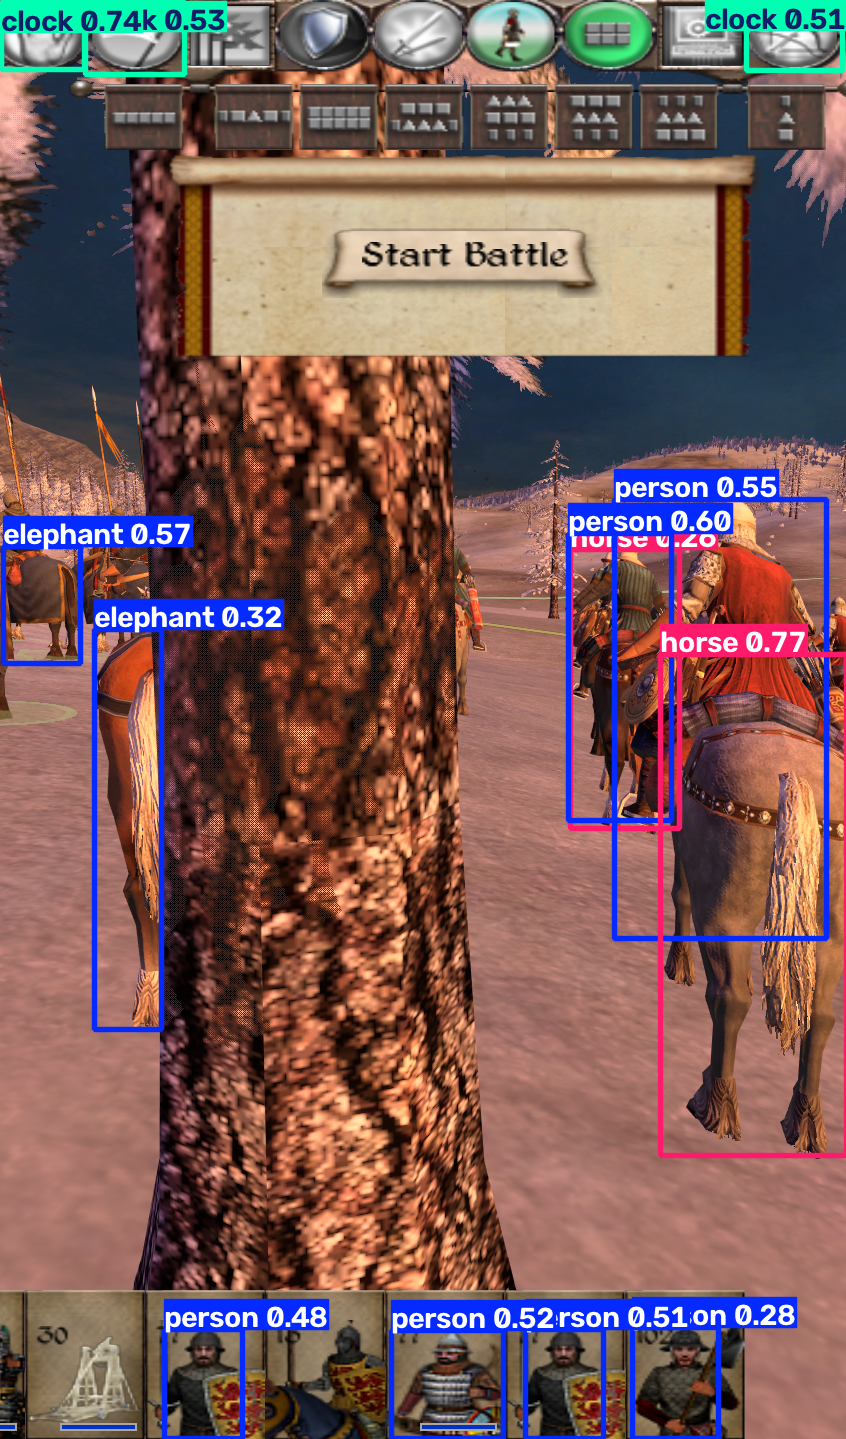

In [12]:
from ultralytics import YOLO
from google.colab import files
import torch # Import torch for torch.cuda.is_available()

model = YOLO("yolov8n.pt")
uploaded = files.upload()

# The files.upload() function returns a dictionary. We need to get the filename
# and save the content to a file, then pass the filename (path) to the model.
# Assuming only one file is uploaded for simplicity.
filename = next(iter(uploaded)) # Get the first filename from the dictionary
with open(filename, 'wb') as f:
    f.write(uploaded[filename]) # Write the binary content to a file

testResults1 = model(filename) # Pass the filename (path) to the model

#good practice to robustly define device
#only attempts to utilize cuda if cuda is available
device = 'cuda' if torch.cuda.is_available() else 'cpu'

for result in testResults1:
  boxes = result.boxes
  masks = result.masks
  keypoints = result.keypoints
  probs = result.probs
  print(boxes)
  print(masks)
  print(keypoints)
  print(probs)
  result.show()